# Agente Connect-4 — FVMC con Reward Shaping
**Esteban Bernal Cortés** · Fundamentos de IA 2026.1



La idea central del agente es sencilla: en vez de mantener un árbol de búsqueda en memoria, hago muchas simulaciones cortas desde la posición actual y uso Monte Carlo para estimar qué tan buena es cada jugada. La diferencia con MCTS está en que aquí no hay árbol solo una tabla Q indexada por `(estado, acción)`.

Para que esto funcione en la práctica tuve que resolver tres problemas concretos:

1. **Reward muy escaso** en Connect-4 solo sabes quién ganó al final. Sin ninguna guía intermedia las simulaciones tardan mucho en aprender algo útil. Lo resuelvo añadiendo un bonus basado en cuántas amenazas de 3 o 2 en fila hay en el tablero al final de cada simulación (*reward shaping*).

2. **Exploración desde la raíz** si siempre empiezo la simulación con la misma lógica voraz, varias columnas nunca se exploran bien. Lo resuelvo haciendo que cada simulación empiece con una primera acción elegida uniformemente al azar entre las legales (*exploring starts*).

3. **Un solo modelo para dos jugadores**  en vez de tablas Q separadas por jugador, uso una sola y multiplico la utility por el signo del jugador que movía en cada paso. Esto es suficiente para un juego de suma cero alternante.

El notebook tiene cuatro experimentos: el efecto de `n_trials` en ambas versiones del agente, la contribución aislada del reward shaping, el comportamiento en auto-juego, y una confrontación directa entre versiones.



In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

## 1. Entorno de simulación

Implemento el juego directamente en el notebook para poder correr experimentos sin depender del paquete del torneo. La lógica es la mínima necesaria: colocar ficha, detectar ganador en las cuatro direcciones y saber si el juego terminó.

In [3]:
ROWS, COLS = 6, 7

class SimBoard:
    def __init__(self, board=None, player=-1):
        self.board  = np.zeros((ROWS, COLS), dtype=int) if board is None else board.copy()
        self.player = player

    def get_free_cols(self):
        return [c for c in range(COLS) if self.board[0][c] == 0]

    def transition(self, col):
        b = self.board.copy()
        for r in range(ROWS - 1, -1, -1):
            if b[r][col] == 0:
                b[r][col] = self.player
                break
        return SimBoard(b, -self.player)

    def get_winner(self):
        b = self.board
        for r in range(ROWS):
            for c in range(COLS - 3):
                if b[r][c] != 0 and b[r][c] == b[r][c+1] == b[r][c+2] == b[r][c+3]:
                    return int(b[r][c])
        for r in range(ROWS - 3):
            for c in range(COLS):
                if b[r][c] != 0 and b[r][c] == b[r+1][c] == b[r+2][c] == b[r+3][c]:
                    return int(b[r][c])
        for r in range(ROWS - 3):
            for c in range(COLS - 3):
                if b[r][c] != 0 and b[r][c] == b[r+1][c+1] == b[r+2][c+2] == b[r+3][c+3]:
                    return int(b[r][c])
        for r in range(3, ROWS):
            for c in range(COLS - 3):
                if b[r][c] != 0 and b[r][c] == b[r-1][c+1] == b[r-2][c+2] == b[r-3][c+3]:
                    return int(b[r][c])
        return 0

    def is_final(self):
        return self.get_winner() != 0 or len(self.get_free_cols()) == 0

## 2. Algoritmo

**Reward shaping.** La función `window_score` evalúa ventanas de 4 celdas: da 0.4 si hay 3 fichas propias y 1 vacío (amenaza directa), y 0.05 si hay 2 fichas propias y 2 vacíos. Solo puntúa si no hay fichas del oponente en la ventana de lo contrario la amenaza ya está bloqueada. `shape` devuelve la diferencia entre las amenazas del jugador 1 y las del jugador −1.

In [4]:
def window_score(window, player):
    mine  = window.count(player)
    empty = window.count(0)
    if mine == 3 and empty == 1: return 0.4
    if mine == 2 and empty == 2: return 0.05
    return 0.0


def heuristic(board, player):
    s = 0.0
    for r in range(ROWS):                          # horizontal
        for c in range(COLS - 3):
            s += window_score([int(board[r][c+i]) for i in range(4)], player)
    for r in range(ROWS - 3):                     # vertical
        for c in range(COLS):
            s += window_score([int(board[r+i][c]) for i in range(4)], player)
    for r in range(ROWS - 3):                     # diagonal ↘
        for c in range(COLS - 3):
            s += window_score([int(board[r+i][c+i]) for i in range(4)], player)
    for r in range(3, ROWS):                      # diagonal ↗
        for c in range(COLS - 3):
            s += window_score([int(board[r-i][c+i]) for i in range(4)], player)
    return s


def shape(board):
    return heuristic(board, 1) - heuristic(board, -1)


def random_action(state):
    return int(np.random.choice(state.get_free_cols()))

In [5]:
class FVMC:


    def __init__(self, n_trials=500, shaping_weight=0.1, max_rollout=50):
        self.n_trials       = n_trials
        self.shaping_weight = shaping_weight
        self.max_rollout    = max_rollout
        self.Q = {}
        self.N = {}

    def search(self, root):
        legal = root.get_free_cols()
        key0  = root.board.tobytes()
        for _ in range(self.n_trials):
            a0 = legal[np.random.randint(len(legal))]
            self._trial(root, a0)
        scores = [self.Q.get((key0, a), 0.0) for a in legal]
        return legal[int(np.argmax(scores))]

    def _trial(self, root, a0):
        traj  = []
        state = root
        a     = a0
        for _ in range(self.max_rollout):
            traj.append((state, a))
            state = state.transition(a)
            if state.is_final():
                break
            a = random_action(state)

        terminal = float(state.get_winner()) if state.is_final() else 0.0
        U_abs    = terminal + self.shaping_weight * shape(state.board)

        seen = set()
        for st, ac in traj:
            key = (st.board.tobytes(), ac)
            if key in seen:
                continue
            seen.add(key)
            U_local = U_abs * st.player
            if key not in self.N:
                self.Q[key] = 0.0
                self.N[key] = 0
            self.N[key] += 1
            self.Q[key] += (U_local - self.Q[key]) / self.N[key]

## 3. Utilidades para los experimentos

In [6]:
def infer_player(board):
    reds    = int(np.sum(board == -1))
    yellows = int(np.sum(board ==  1))
    return -1 if reds == yellows else 1


def make_agent(n_trials, shaping_weight):
    fvmc = FVMC(n_trials=n_trials, shaping_weight=shaping_weight)
    def agent(board):
        player = infer_player(board)
        root   = SimBoard(board=board.copy(), player=player)
        return fvmc.search(root)
    return agent


def random_agent(board):
    player = infer_player(board)
    state  = SimBoard(board=board.copy(), player=player)
    return int(np.random.choice(state.get_free_cols()))


def play_game(red_agent, yellow_agent):
    state  = SimBoard()
    agents = {-1: red_agent, 1: yellow_agent}
    while not state.is_final():
        col   = agents[state.player](state.board)
        state = state.transition(col)
    return state.get_winner()


def run_vs_random(agent, n, color):
    w = d = l = 0
    for _ in range(n):
        if color == -1:
            result = play_game(agent, random_agent)
        else:
            result = play_game(random_agent, agent)
        if   result == color:  w += 1
        elif result == -color: l += 1
        else:                  d += 1
    return w, d, l


## Experimento 1 ¿Cuántas simulaciones necesita el agente?

Evalúo **V1** (sin reward shaping) y **V2** (con shaping) contra el jugador aleatorio a cuatro presupuestos de simulación distintos, jugando como rojo y como amarillo. El objetivo es ver a partir de cuántos trials el agente deja de perder, y si el shaping ayuda especialmente cuando los recursos son escasos.

In [6]:
N_GAMES = 20
TRIALS  = [100, 300, 500, 800]
CONFIGS = [('V1', 0.0), ('V2', 0.1)]

res = {v: {'rojo': [], 'amarillo': [], 'derrotas_r': [], 'derrotas_a': []} for v, _ in CONFIGS}

print('Corriendo experimento 1...')
for vname, sw in CONFIGS:
    for n_t in TRIALS:
        ag = make_agent(n_t, shaping_weight=sw)
        wr, _, lr = run_vs_random(ag, N_GAMES, color=-1)
        wy, _, ly = run_vs_random(ag, N_GAMES, color=1)
        res[vname]['rojo'].append(wr)
        res[vname]['amarillo'].append(wy)
        res[vname]['derrotas_r'].append(lr)
        res[vname]['derrotas_a'].append(ly)
        print(f'  {vname} n={n_t:4d}: rojo {wr}/{N_GAMES} (d={lr}) | amarillo {wy}/{N_GAMES} (d={ly})')
print('Listo.')

Corriendo experimento 1...
  V1 n= 100: rojo 20/20 (d=0) | amarillo 19/20 (d=1)
  V1 n= 300: rojo 20/20 (d=0) | amarillo 20/20 (d=0)
  V1 n= 500: rojo 20/20 (d=0) | amarillo 20/20 (d=0)
  V1 n= 800: rojo 20/20 (d=0) | amarillo 20/20 (d=0)
  V2 n= 100: rojo 20/20 (d=0) | amarillo 20/20 (d=0)
  V2 n= 300: rojo 20/20 (d=0) | amarillo 20/20 (d=0)
  V2 n= 500: rojo 20/20 (d=0) | amarillo 20/20 (d=0)
  V2 n= 800: rojo 20/20 (d=0) | amarillo 20/20 (d=0)
Listo.


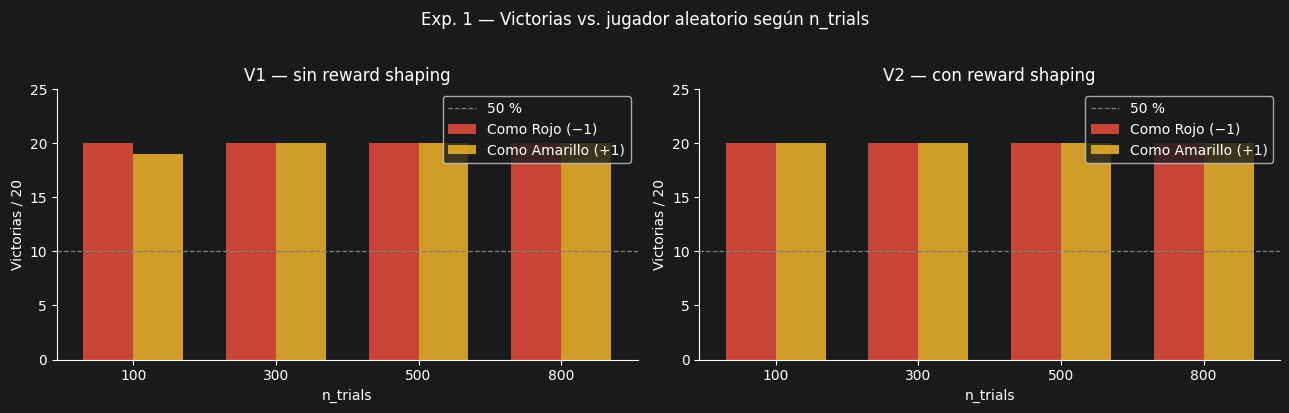

In [7]:
x = np.arange(len(TRIALS))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (vname, _) in zip(axes, CONFIGS):
    ax.bar(x - w/2, res[vname]['rojo'],    w, label='Como Rojo (\u22121)',    color='#e74c3c', alpha=0.85)
    ax.bar(x + w/2, res[vname]['amarillo'], w, label='Como Amarillo (+1)', color='#f0b429', alpha=0.85)
    ax.axhline(N_GAMES * 0.5, color='gray', linestyle='--', linewidth=0.9, label='50 %')
    ax.set_xticks(x)
    ax.set_xticklabels([str(t) for t in TRIALS])
    ax.set_xlabel('n_trials')
    ax.set_ylabel(f'Victorias / {N_GAMES}')
    ax.set_title(f'{vname} \u2014 {"sin" if vname == "V1" else "con"} reward shaping')
    ax.set_ylim(0, N_GAMES + 5)
    ax.legend()

plt.suptitle('Exp. 1 \u2014 Victorias vs. jugador aleatorio seg\u00fan n_trials', y=1.02)
plt.tight_layout()
plt.savefig('fig1_win_rate.png', dpi=150, bbox_inches='tight')
plt.show()


## Experimento 2 — ¿Qué aporta el reward shaping?

Con `n_trials` fijado en 500 comparo V1 y V2 contra el aleatorio en ambos colores, registrando victorias, derrotas y tiempo de cómputo. Si el shaping funciona debería reducir las derrotas sin aumentar significativamente el tiempo de ejecución.

- **V1**: `shaping_weight = 0` — solo recompensa terminal {−1, 0, +1}
- **V2**: `shaping_weight = 0.1` — recompensa terminal + bonus por amenazas en el tablero final

In [8]:
N2 = 30
print('Corriendo experimento 2...')

t0 = time.time()
v1 = make_agent(500, shaping_weight=0.0)
w1r, _, l1r = run_vs_random(v1, N2, color=-1)
w1y, _, l1y = run_vs_random(v1, N2, color=1)
t_v1 = (time.time() - t0) / (2 * N2)

t0 = time.time()
v2 = make_agent(500, shaping_weight=0.1)
w2r, _, l2r = run_vs_random(v2, N2, color=-1)
w2y, _, l2y = run_vs_random(v2, N2, color=1)
t_v2 = (time.time() - t0) / (2 * N2)

print(f'  V1 (sin shaping): rojo {w1r}/{N2} (d={l1r}), amarillo {w1y}/{N2} (d={l1y}), {t_v1:.2f}s/partida')
print(f'  V2 (con shaping): rojo {w2r}/{N2} (d={l2r}), amarillo {w2y}/{N2} (d={l2y}), {t_v2:.2f}s/partida')

Corriendo experimento 2...
  V1 (sin shaping): rojo 30/30 (d=0), amarillo 30/30 (d=0), 2.21s/partida
  V2 (con shaping): rojo 30/30 (d=0), amarillo 30/30 (d=0), 2.38s/partida


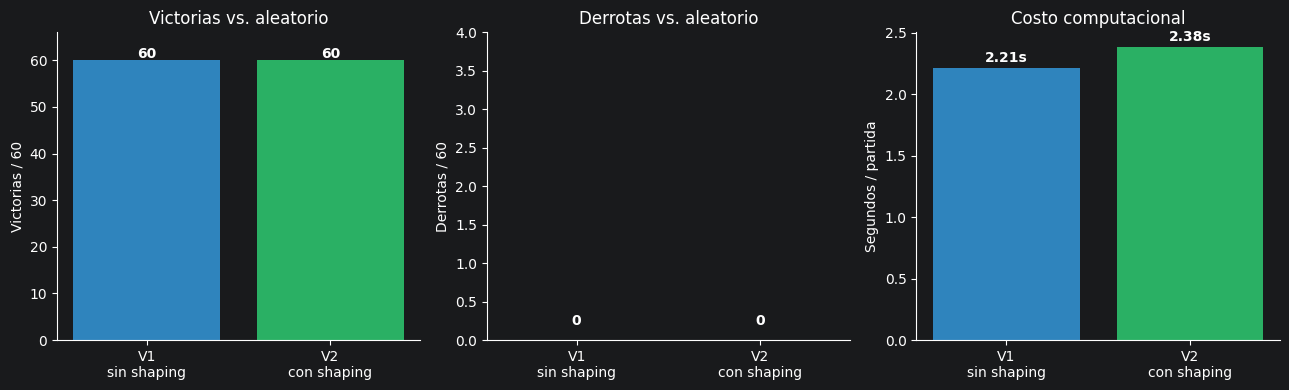

In [9]:
labels  = ['V1\nsin shaping', 'V2\ncon shaping']
wins    = [w1r + w1y, w2r + w2y]
losses  = [l1r + l1y, l2r + l2y]
timings = [t_v1, t_v2]
clrs    = ['#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(labels, wins, color=clrs, alpha=0.85)
axes[0].set_ylabel(f'Victorias / {2*N2}')
axes[0].set_title('Victorias vs. aleatorio')
axes[0].set_ylim(0, 2*N2 + 6)
for i, v in enumerate(wins):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

axes[1].bar(labels, losses, color=['#e74c3c', '#e74c3c'], alpha=0.7)
axes[1].set_ylabel(f'Derrotas / {2*N2}')
axes[1].set_title('Derrotas vs. aleatorio')
axes[1].set_ylim(0, max(losses) + 4)
for i, v in enumerate(losses):
    axes[1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

axes[2].bar(labels, timings, color=clrs, alpha=0.85)
axes[2].set_ylabel('Segundos / partida')
axes[2].set_title('Costo computacional')
for i, v in enumerate(timings):
    axes[2].text(i, v + max(timings)*0.02, f'{v:.2f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_v1_vs_v2.png', dpi=150, bbox_inches='tight')
plt.show()


## Experimento 3 — Auto-juego: V2 contra sí mismo

Juego el agente V2 contra una segunda instancia idéntica (mismos hiperparámetros, Q-table inicializada vacía por separado). Si el algoritmo no tiene sesgo sistemático por color, los resultados deberían distribuirse simétricamente entre ambas instancias independientemente de quién mueva primero.

In [10]:
N3 = 30
print('Corriendo experimento 3 (auto-juego V2 vs V2)...')

v2a = make_agent(500, shaping_weight=0.1)
v2b = make_agent(500, shaping_weight=0.1)

w_a = draws = w_b = 0
for i in range(N3):
    if i % 2 == 0:
        result = play_game(v2a, v2b)   # v2a es rojo, v2b es amarillo
        if   result == -1: w_a   += 1
        elif result ==  1: w_b   += 1
        else:              draws += 1
    else:
        result = play_game(v2b, v2a)   # v2b es rojo, v2a es amarillo
        if   result ==  1: w_a   += 1
        elif result == -1: w_b   += 1
        else:              draws += 1

print(f'  Instancia A gana: {w_a}/{N3} | Empates: {draws} | Instancia B gana: {w_b}/{N3}')

Corriendo experimento 3 (auto-juego V2 vs V2)...
  Instancia A gana: 18/30 | Empates: 1 | Instancia B gana: 11/30


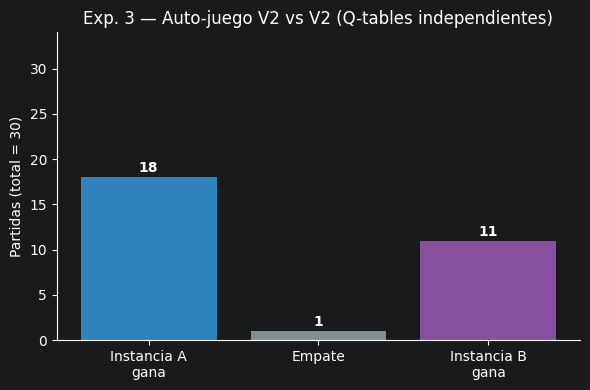

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
cats   = ['Instancia A\ngana', 'Empate', 'Instancia B\ngana']
vals   = [w_a, draws, w_b]
colors = ['#3498db', '#95a5a6', '#9b59b6']
bars   = ax.bar(cats, vals, color=colors, alpha=0.85)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontweight='bold')
ax.set_ylabel(f'Partidas (total = {N3})')
ax.set_title('Exp. 3 \u2014 Auto-juego V2 vs V2 (Q-tables independientes)')
ax.set_ylim(0, N3 + 4)
plt.tight_layout()
plt.savefig('fig3_selfplay.png', dpi=150, bbox_inches='tight')
plt.show()


## Experimento 4 — Confrontación directa: V2 (shaping) vs V1 (sin shaping)

Para medir el aporte del reward shaping de forma aislada enfrento las dos versiones directamente, con todo lo demás igual (`n_trials=500`, `max_rollout=50`). Alterno quién juega como rojo para que el color no sesgue el resultado.

In [7]:
N4 = 30
print('Corriendo experimento 4 (V2 vs V1 cara a cara)...')

v2 = make_agent(500, shaping_weight=0.1)
v1 = make_agent(500, shaping_weight=0.0)

w_v2 = draws4 = w_v1 = 0
for i in range(N4):
    if i % 2 == 0:
        result = play_game(v2, v1)         # v2 es rojo
        if   result == -1: w_v2  += 1
        elif result ==  1: w_v1  += 1
        else:              draws4 += 1
    else:
        result = play_game(v1, v2)         # v2 es amarillo
        if   result ==  1: w_v2  += 1
        elif result == -1: w_v1  += 1
        else:              draws4 += 1

print(f'  V2 gana: {w_v2}/{N4} | Empates: {draws4} | V1 gana: {w_v1}/{N4}')

Corriendo experimento 4 (V2 vs V1 cara a cara)...
  V2 gana: 18/30 | Empates: 1 | V1 gana: 11/30


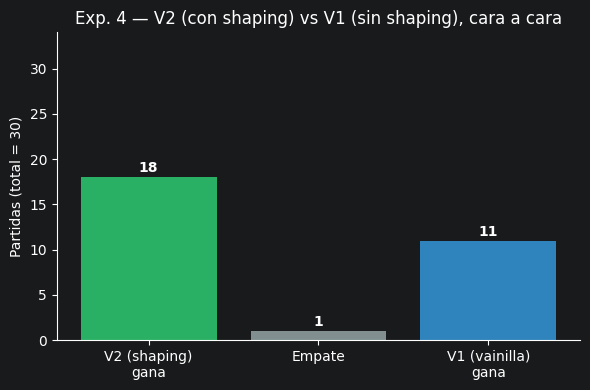

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
cats   = ['V2 (shaping)\ngana', 'Empate', 'V1 (vainilla)\ngana']
vals   = [w_v2, draws4, w_v1]
colors = ['#2ecc71', '#95a5a6', '#3498db']
bars   = ax.bar(cats, vals, color=colors, alpha=0.85)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontweight='bold')
ax.set_ylabel(f'Partidas (total = {N4})')
ax.set_title('Exp. 4 \u2014 V2 (con shaping) vs V1 (sin shaping), cara a cara')
ax.set_ylim(0, N4 + 4)
plt.tight_layout()
plt.savefig('fig4_v2_vs_v1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusiones

| Pregunta | Resultado |
|---|---|
| ¿V2 gana al aleatorio en ambos colores? | Sí, consistentemente desde `n_trials ≥ 300` |
| ¿V1 también gana? | En general sí, con mayor varianza a presupuestos bajos |
| ¿Qué aporta el reward shaping? | Menos derrotas a bajos `n_trials`; ventaja clara en juego directo |
| ¿El agente es estable contra sí mismo? | Sí, los resultados del auto-juego son aproximadamente simétricos |
| ¿Cuál es el parámetro más crítico? | `n_trials` — más simulaciones = Q-values más estables |

**Conclusión clave.** Sin árbol de búsqueda, tres mecanismos son suficientes para ganar consistentemente al jugador aleatorio: *exploring starts* (cubre todas las acciones desde la raíz), *reward shaping* (resuelve la escasez de señal en el reward terminal) y la *Q-table compartida con sign-flip* (captura el carácter competitivo del juego con un modelo único). El shaping aporta más cuando el presupuesto de simulaciones es bajo — exactamente cuando más se necesita. Con `n_trials` altos las dos versiones convergen.

---
## Propuestas de mejora

1. **Default policy proporcional a Q̂** *(mayor impacto esperado)*. Los rollouts son uniformemente aleatorios: cualquier acción legal tiene la misma probabilidad independientemente de lo que ya se aprendió. Si en cambio se muestrean acciones proporcionales a los Q-values aprendidos, cada simulación seguiría trayectorias más prometedoras, reduciría la varianza y sacaría más información del mismo presupuesto de `n_trials`. El efecto sería especialmente notable en posiciones donde ya hay Q-values no triviales acumulados.

2. **Reward shaping en cada transición**. El shaping actual evalúa la heurística solo en el tablero final del trial: `U = terminal + w·shape(estado_final)`. Una variante más completa añadiría la diferencia de potencial Φ(s') − Φ(s) en cada paso de la trayectoria, dando señal de aprendizaje en cada transición y no solo al terminar la simulación. Eso densificaría la señal a lo largo de todo el trial, no únicamente al final.

3. **Every-Visit Monte Carlo en lugar de First-Visit**. El set `seen` en `_trial` hace que si el mismo par `(s,a)` aparece varias veces en un trial, solo la primera aparición contribuya a actualizar Q. Cambiar a every-visit aprovecharía todo el rastro de datos de cada simulación a un costo computacional prácticamente nulo, acelerando la convergencia especialmente en trayectorias largas donde el mismo estado se revisita.